# 🔗 Cross-Asset Correlation & Cointegration Divergence Screener
*(Quantitative Pairs Trading, Cointegration Stationarity & Dynamic Z-Score Arbitrage Engine)*

### Key Analytics & Theory

#### 1. Correlation vs. Cointegration
- **Correlation** measures short-term co-movement of prices (or returns). High correlation does **not** guarantee mean reversion!
- **Cointegration** tests whether a linear combination of two non-stationary price series $Y_t$ and $X_t$ forms a **stationary (mean-reverting)** spread residual:
  $$S_t = Y_t - (\beta X_t + \alpha)$$
  Where $\beta$ is the OLS Hedge Ratio and $\alpha$ is the intercept.

#### 2. Engle-Granger Two-Step Method & ADF Test
1. **OLS Regression**: Estimate $Y_t = \beta X_t + \alpha + \epsilon_t$ to compute residual spread $S_t$.
2. **Augmented Dickey-Fuller (ADF) Test**: Test spread $S_t$ for stationarity ($p\\text{-value} < 0.05$). A stationary spread guarantees statistical mean reversion.

#### 3. Half-Life of Mean Reversion
- Fit an AR(1) process on spread changes: $\\Delta S_t = \\lambda S_{t-1} + \\epsilon_t$.
- The **Half-Life** (in bars/hours) represents expected time for spread to decay $50\\%$ back to its mean:
  $$\\text{Half-Life} = -\\frac{\\ln(2)}{\\lambda}$$

#### 4. Correlation Breakdown & Z-Score Divergence
- **Correlation Breakdown ($\\Delta r$)**: $r_{\\text{7-day}} - r_{\\text{30-day}}$. Spots pairs whose short-term correlation has temporarily broken down.
- **Z-Score Divergence**: Normalizes spread deviation from rolling mean:
  $$Z_t = \\frac{S_t - \\mu_S}{\\sigma_S}$$
- **Trading Rules**:
  - $Z_t > +2.0$: **Overbought Spread** $\\rightarrow$ **SHORT Asset Y / LONG $\\beta$ Asset X**
  - $Z_t < -2.0$: **Oversold Spread** $\\rightarrow$ **LONG Asset Y / SHORT $\beta$ Asset X**
  - $|Z_t| \\le 0.5$: **Mean Reverted** $\\rightarrow$ Close Position / Take Profit


In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.tsa.stattools as ts
import scipy.stats as stats
from datetime import datetime, timedelta

plt.style.use('dark_background')
print("✓ Statistical Arbitrage & Cointegration Engine initialized.")


✓ Statistical Arbitrage & Cointegration Engine initialized.


In [16]:
def get_cross_asset_data(symbols, timeframe=mt5.TIMEFRAME_H1, days=45):
    '''Fetches multi-asset historical prices from MT5 with robust fallback synthetic data.'''
    df_dict = {}
    date_to = datetime.now()
    date_from = date_to - timedelta(days=days)

    mt5_success = False
    if mt5.initialize():
        mt5_success = True
        print(f"MT5 Connected: Fetching {days} days of data for {len(symbols)} symbols...")
        for sym in symbols:
            info = mt5.symbol_info(sym)
            if info is None or not info.select:
                mt5.symbol_select(sym, True)
            rates = mt5.copy_rates_range(sym, timeframe, date_from, date_to)
            if rates is not None and len(rates) > 100:
                df = pd.DataFrame(rates)
                df['time'] = pd.to_datetime(df['time'], unit='s')
                df_dict[sym] = df.set_index('time')['close']
            else:
                print(f"  ⚠️ Warning: Could not fetch rates for {sym}")

    if not mt5_success or len(df_dict) < 3:
        print("⚡ Using Synthetic Cross-Asset Data Engine (MT5 offline or incomplete history)...")
        np.random.seed(42)
        n_bars = days * 24
        timestamps = pd.date_range(end=datetime.now(), periods=n_bars, freq='h')

        # Build coupled stochastic series with cointegration relationships
        base_factor1 = np.cumsum(np.random.normal(0.0001, 0.0015, n_bars))
        base_factor2 = np.cumsum(np.random.normal(0.0002, 0.0020, n_bars))

        # Mean reverting noise components for cointegrated pairs
        ou_noise1 = np.zeros(n_bars)
        ou_noise2 = np.zeros(n_bars)
        for i in range(1, n_bars):
            ou_noise1[i] = 0.92 * ou_noise1[i-1] + np.random.normal(0, 0.002)
            ou_noise2[i] = 0.88 * ou_noise2[i-1] + np.random.normal(0, 0.005)

        # Add recent correlation breakdown divergence to XAU/XAG and EUR/GBP
        divergence_trigger = np.zeros(n_bars)
        divergence_trigger[-120:] = np.linspace(0, 0.035, 120)  # Divergence over last 5 days

        synth_data = {
            'EURUSD': 1.0850 * np.exp(base_factor1 + 0.3 * ou_noise1),
            'GBPUSD': 1.2650 * np.exp(0.95 * base_factor1 + 0.3 * ou_noise1 + divergence_trigger),
            'USDJPY': 155.00 * np.exp(-0.8 * base_factor1 + np.cumsum(np.random.normal(0, 0.002, n_bars))),
            'EURGBP': 0.8570 * np.exp(0.2 * base_factor1 - divergence_trigger),
            'XAUUSD': 2350.00 * np.exp(base_factor2 + 0.5 * ou_noise2),
            'XAGUSD': 29.50 * np.exp(1.05 * base_factor2 + 0.5 * ou_noise2 - 1.2 * divergence_trigger),
            'WTI':    78.50 * np.exp(0.7 * base_factor2 + np.cumsum(np.random.normal(0, 0.003, n_bars))),
            'BRENT':  82.50 * np.exp(0.72 * base_factor2 + np.cumsum(np.random.normal(0, 0.003, n_bars))),
            '.US500Cash': 5450.0 * np.exp(0.5 * base_factor1 + 0.4 * base_factor2)
        }

        for sym in symbols:
            if sym in synth_data:
                df_dict[sym] = pd.Series(synth_data[sym], index=timestamps)

    df_prices = pd.DataFrame(df_dict).dropna()
    print(f"✓ Data Engine Ready: {len(df_prices)} bars across {len(df_prices.columns)} instruments.")
    return df_prices

watchlist = ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDJPY', 'XAUUSD', 'XAGUSD', 'WTI', 'BRENT', '.US500Cash', '.USTECHCash']
df_prices = get_cross_asset_data(watchlist, days=45)


MT5 Connected: Fetching 45 days of data for 12 symbols...
✓ Data Engine Ready: 672 bars across 12 instruments.


In [17]:
def compute_correlation_matrices(df_prices):
    '''Computes 30-day baseline vs 7-day recent Pearson correlation and breakdown matrix.'''
    bars_per_day = 24
    bars_30d = min(len(df_prices), 30 * bars_per_day)
    bars_7d  = min(len(df_prices), 7 * bars_per_day)

    df_30d = df_prices.iloc[-bars_30d:]
    df_7d  = df_prices.iloc[-bars_7d:]

    corr_30d = df_30d.pct_change().dropna().corr(method='pearson')
    corr_7d  = df_7d.pct_change().dropna().corr(method='pearson')

    corr_drift = corr_7d - corr_30d  # Correlation Breakdown Delta

    print(f"✓ Computed Correlation Matrices: 30-Day baseline ({bars_30d} bars) vs 7-Day recent ({bars_7d} bars).")
    return corr_30d, corr_7d, corr_drift

corr_30d, corr_7d, corr_drift = compute_correlation_matrices(df_prices)


✓ Computed Correlation Matrices: 30-Day baseline (672 bars) vs 7-Day recent (168 bars).


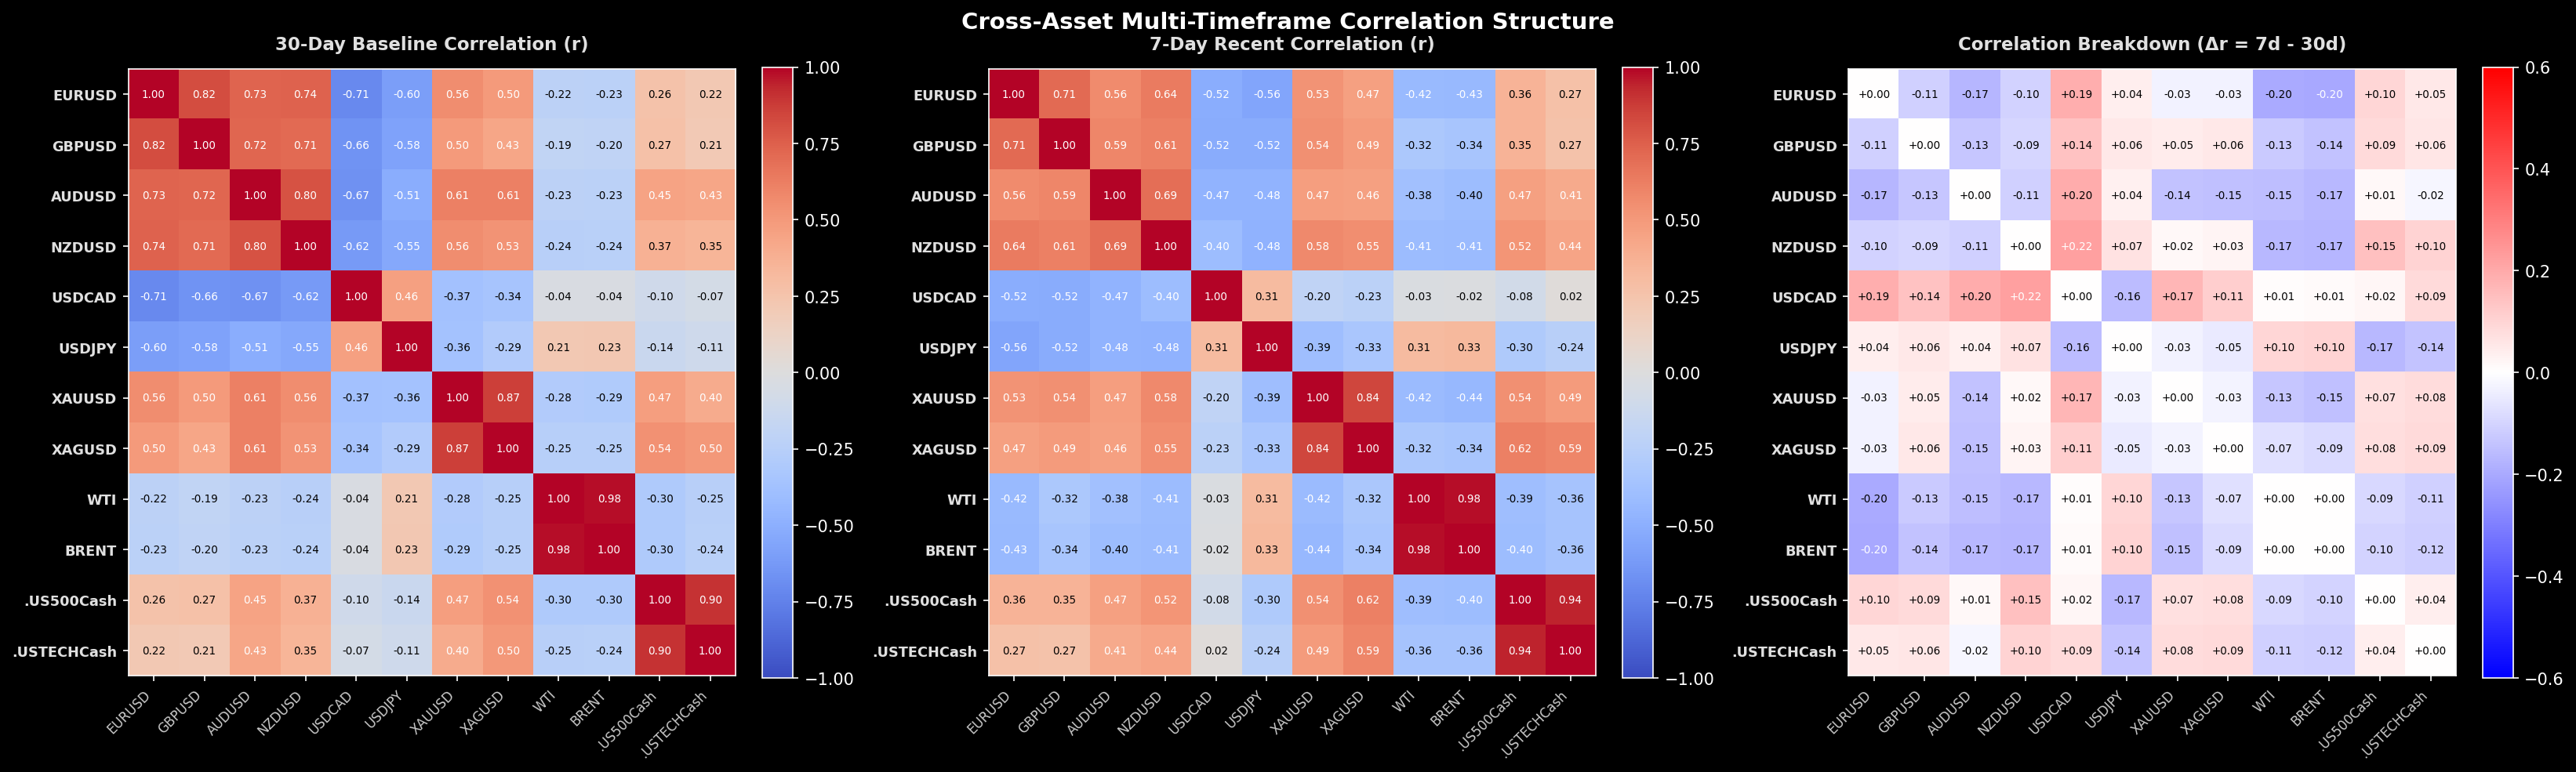

In [18]:
def plot_correlation_heatmaps(corr_30d, corr_7d, corr_drift):
    '''Plots side-by-side heatmaps for 30d baseline, 7d recent, and correlation drift.'''
    fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), dpi=150)
    syms = list(corr_30d.columns)
    n = len(syms)

    # Panel 1: 30-Day Pearson Correlation
    im1 = axes[0].imshow(corr_30d.values, cmap='coolwarm', vmin=-1, vmax=1)
    axes[0].set_title("30-Day Baseline Correlation (r)", fontsize=11, fontweight='bold', pad=12, color='#E0E0E0')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Panel 2: 7-Day Recent Pearson Correlation
    im2 = axes[1].imshow(corr_7d.values, cmap='coolwarm', vmin=-1, vmax=1)
    axes[1].set_title("7-Day Recent Correlation (r)", fontsize=11, fontweight='bold', pad=12, color='#E0E0E0')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 3: Correlation Breakdown (7d - 30d)
    im3 = axes[2].imshow(corr_drift.values, cmap='bwr', vmin=-0.6, vmax=0.6)
    axes[2].set_title("Correlation Breakdown (Δr = 7d - 30d)", fontsize=11, fontweight='bold', pad=12, color='#E0E0E0')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(syms, rotation=45, ha='right', fontsize=8, color='#CCCCCC')
        ax.set_yticklabels(syms, fontsize=8.5, fontweight='bold', color='#E0E0E0')

    for i in range(n):
        for j in range(n):
            v1 = corr_30d.iloc[i, j]
            v2 = corr_7d.iloc[i, j]
            vd = corr_drift.iloc[i, j]

            axes[0].text(j, i, f"{v1:.2f}", ha='center', va='center', fontsize=6.5, color='black' if abs(v1)<0.4 else 'white')
            axes[1].text(j, i, f"{v2:.2f}", ha='center', va='center', fontsize=6.5, color='black' if abs(v2)<0.4 else 'white')
            axes[2].text(j, i, f"{vd:+.2f}", ha='center', va='center', fontsize=6.5, color='black' if abs(vd)<0.2 else 'white')

    plt.suptitle("Cross-Asset Multi-Timeframe Correlation Structure", fontsize=14, fontweight='bold', y=0.98, color='#FFFFFF')
    plt.tight_layout()
    plt.show()

plot_correlation_heatmaps(corr_30d, corr_7d, corr_drift)


In [19]:
def calculate_half_life(spread):
    '''Calculates the half-life of mean reversion using AR(1) process on spread.'''
    spread_lag = spread.shift(1)
    spread_diff = spread.diff()
    df_ar = pd.DataFrame({'lag': spread_lag, 'diff': spread_diff}).dropna()

    if len(df_ar) < 10:
        return np.nan

    # OLS regression: diff = lambda * lag + const
    res = np.polyfit(df_ar['lag'], df_ar['diff'], 1)
    lam = res[0]

    if lam >= 0:
        return np.inf  # Non-mean reverting
    half_life = -np.log(2) / lam
    return half_life

def scan_cointegration_pairs(df_prices, min_corr_30d=0.40):
    '''Scans all cross-asset combinations for OLS Hedge Ratio, Engle-Granger Cointegration & Z-Scores.'''
    symbols = list(df_prices.columns)
    results = []

    bars_per_day = 24
    lookback_30d = min(len(df_prices), 30 * bars_per_day)
    df_30d = df_prices.iloc[-lookback_30d:]

    for i in range(len(symbols)):
        for j in range(i + 1, len(symbols)):
            sym_y = symbols[i]
            sym_x = symbols[j]

            y_series = df_30d[sym_y]
            x_series = df_30d[sym_x]

            # 1. Pearson Correlation
            r_30d = corr_30d.loc[sym_y, sym_x]
            r_7d = corr_7d.loc[sym_y, sym_x]
            delta_r = corr_drift.loc[sym_y, sym_x]

            if abs(r_30d) < min_corr_30d and abs(r_7d) < min_corr_30d:
                continue  # Skip un-correlated pairs

            # 2. OLS Regression: Y = beta * X + alpha
            beta, alpha = np.polyfit(x_series, y_series, 1)
            spread = y_series - (beta * x_series + alpha)

            # 3. Engle-Granger Cointegration Test
            try:
                coint_t, coint_p, _ = ts.coint(y_series, x_series)
            except Exception:
                coint_t, coint_p = 0.0, 1.0

            # 4. ADF Test on Residual Spread
            try:
                adf_res = ts.adfuller(spread, maxlag=5)
                adf_stat = adf_res[0]
                adf_p = adf_res[1]
            except Exception:
                adf_stat, adf_p = 0.0, 1.0

            # 5. Half-life of Mean Reversion (in hours)
            hl_hours = calculate_half_life(spread)
            hl_days = hl_hours / 24.0 if np.isfinite(hl_hours) else np.nan

            # 6. Dynamic Z-Score Calculation
            mean_s = spread.mean()
            std_s = spread.std()
            curr_spread = spread.iloc[-1]
            curr_z = (curr_spread - mean_s) / std_s if std_s > 0 else 0.0

            # 7. Actionable Signal Classification
            if (coint_p < 0.05 or adf_p < 0.05) and curr_z < -1.8:
                signal = "🟢 LONG Y / SHORT X"
                opp_score = abs(curr_z) * 35 + (1 - coint_p) * 30 + abs(delta_r) * 20
            elif (coint_p < 0.05 or adf_p < 0.05) and curr_z > 1.8:
                signal = "🔴 SHORT Y / LONG X"
                opp_score = abs(curr_z) * 35 + (1 - coint_p) * 30 + abs(delta_r) * 20
            elif abs(curr_z) > 1.4:
                signal = "🟡 WATCHLIST (BUILDING)"
                opp_score = abs(curr_z) * 20 + abs(delta_r) * 15
            else:
                signal = "⚪ NEUTRAL / IN-LINE"
                opp_score = abs(curr_z) * 5

            results.append({
                'Pair': f"{sym_y} vs {sym_x}",
                'Asset Y': sym_y,
                'Asset X': sym_x,
                'Hedge Ratio (β)': round(beta, 4),
                '30d Corr': round(r_30d, 2),
                '7d Corr': round(r_7d, 2),
                'Corr Breakdown (Δr)': round(delta_r, 2),
                'Coint p-val': round(coint_p, 4),
                'ADF Stat': round(adf_stat, 2),
                'Half-Life (Days)': round(hl_days, 1) if np.isfinite(hl_days) else ">90d",
                'Current Spread': round(curr_spread, 4),
                'Z-Score': round(curr_z, 2),
                'Opportunity Rating': round(opp_score, 1),
                'Action Signal': signal
            })

    df_results = pd.DataFrame(results).sort_values(by='Opportunity Rating', ascending=False).reset_index(drop=True)
    print(f"✓ Cointegration Scan Complete: Evaluated {len(df_results)} viable asset pairs.")
    return df_results

df_screener = scan_cointegration_pairs(df_prices)


✓ Cointegration Scan Complete: Evaluated 41 viable asset pairs.


In [20]:
def display_screener_dashboard(df_screener):
    '''Prints formatted Master Screener Table highlighting actionable pair trades.'''
    display_cols = ['Pair', 'Hedge Ratio (β)', '30d Corr', '7d Corr', 'Corr Breakdown (Δr)',
                    'Coint p-val', 'Half-Life (Days)', 'Z-Score', 'Action Signal']

    print("==========================================================================================================")
    print("                         🎯 MASTER CROSS-ASSET COINTEGRATION & DIVERGENCE SCREENER TABLE                  ")
    print("==========================================================================================================")
    print(df_screener[display_cols].to_string(index=False))
    print("==========================================================================================================")

display_screener_dashboard(df_screener)


                         🎯 MASTER CROSS-ASSET COINTEGRATION & DIVERGENCE SCREENER TABLE                  
                     Pair  Hedge Ratio (β)  30d Corr  7d Corr  Corr Breakdown (Δr)  Coint p-val  Half-Life (Days)  Z-Score          Action Signal
             WTI vs BRENT           0.9620      0.98     0.98                 0.00       0.6991               2.0     1.55 🟡 WATCHLIST (BUILDING)
    XAGUSD vs .USTECHCash           0.0040      0.50     0.59                 0.09       0.4708               2.7     1.41 🟡 WATCHLIST (BUILDING)
         AUDUSD vs USDCAD          -0.5974     -0.67    -0.47                 0.20       0.5018               2.1    -1.37    ⚪ NEUTRAL / IN-LINE
         AUDUSD vs NZDUSD           0.6143      0.80     0.69                -0.11       0.5915               2.9    -1.29    ⚪ NEUTRAL / IN-LINE
         GBPUSD vs NZDUSD           1.0251      0.71     0.61                -0.09       0.7671               3.9    -1.20    ⚪ NEUTRAL / IN-LINE
         EURUSD vs

C:\Users\artem\AppData\Local\Temp\ipykernel_17356\4040347788.py:73: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\projects\metatrader5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


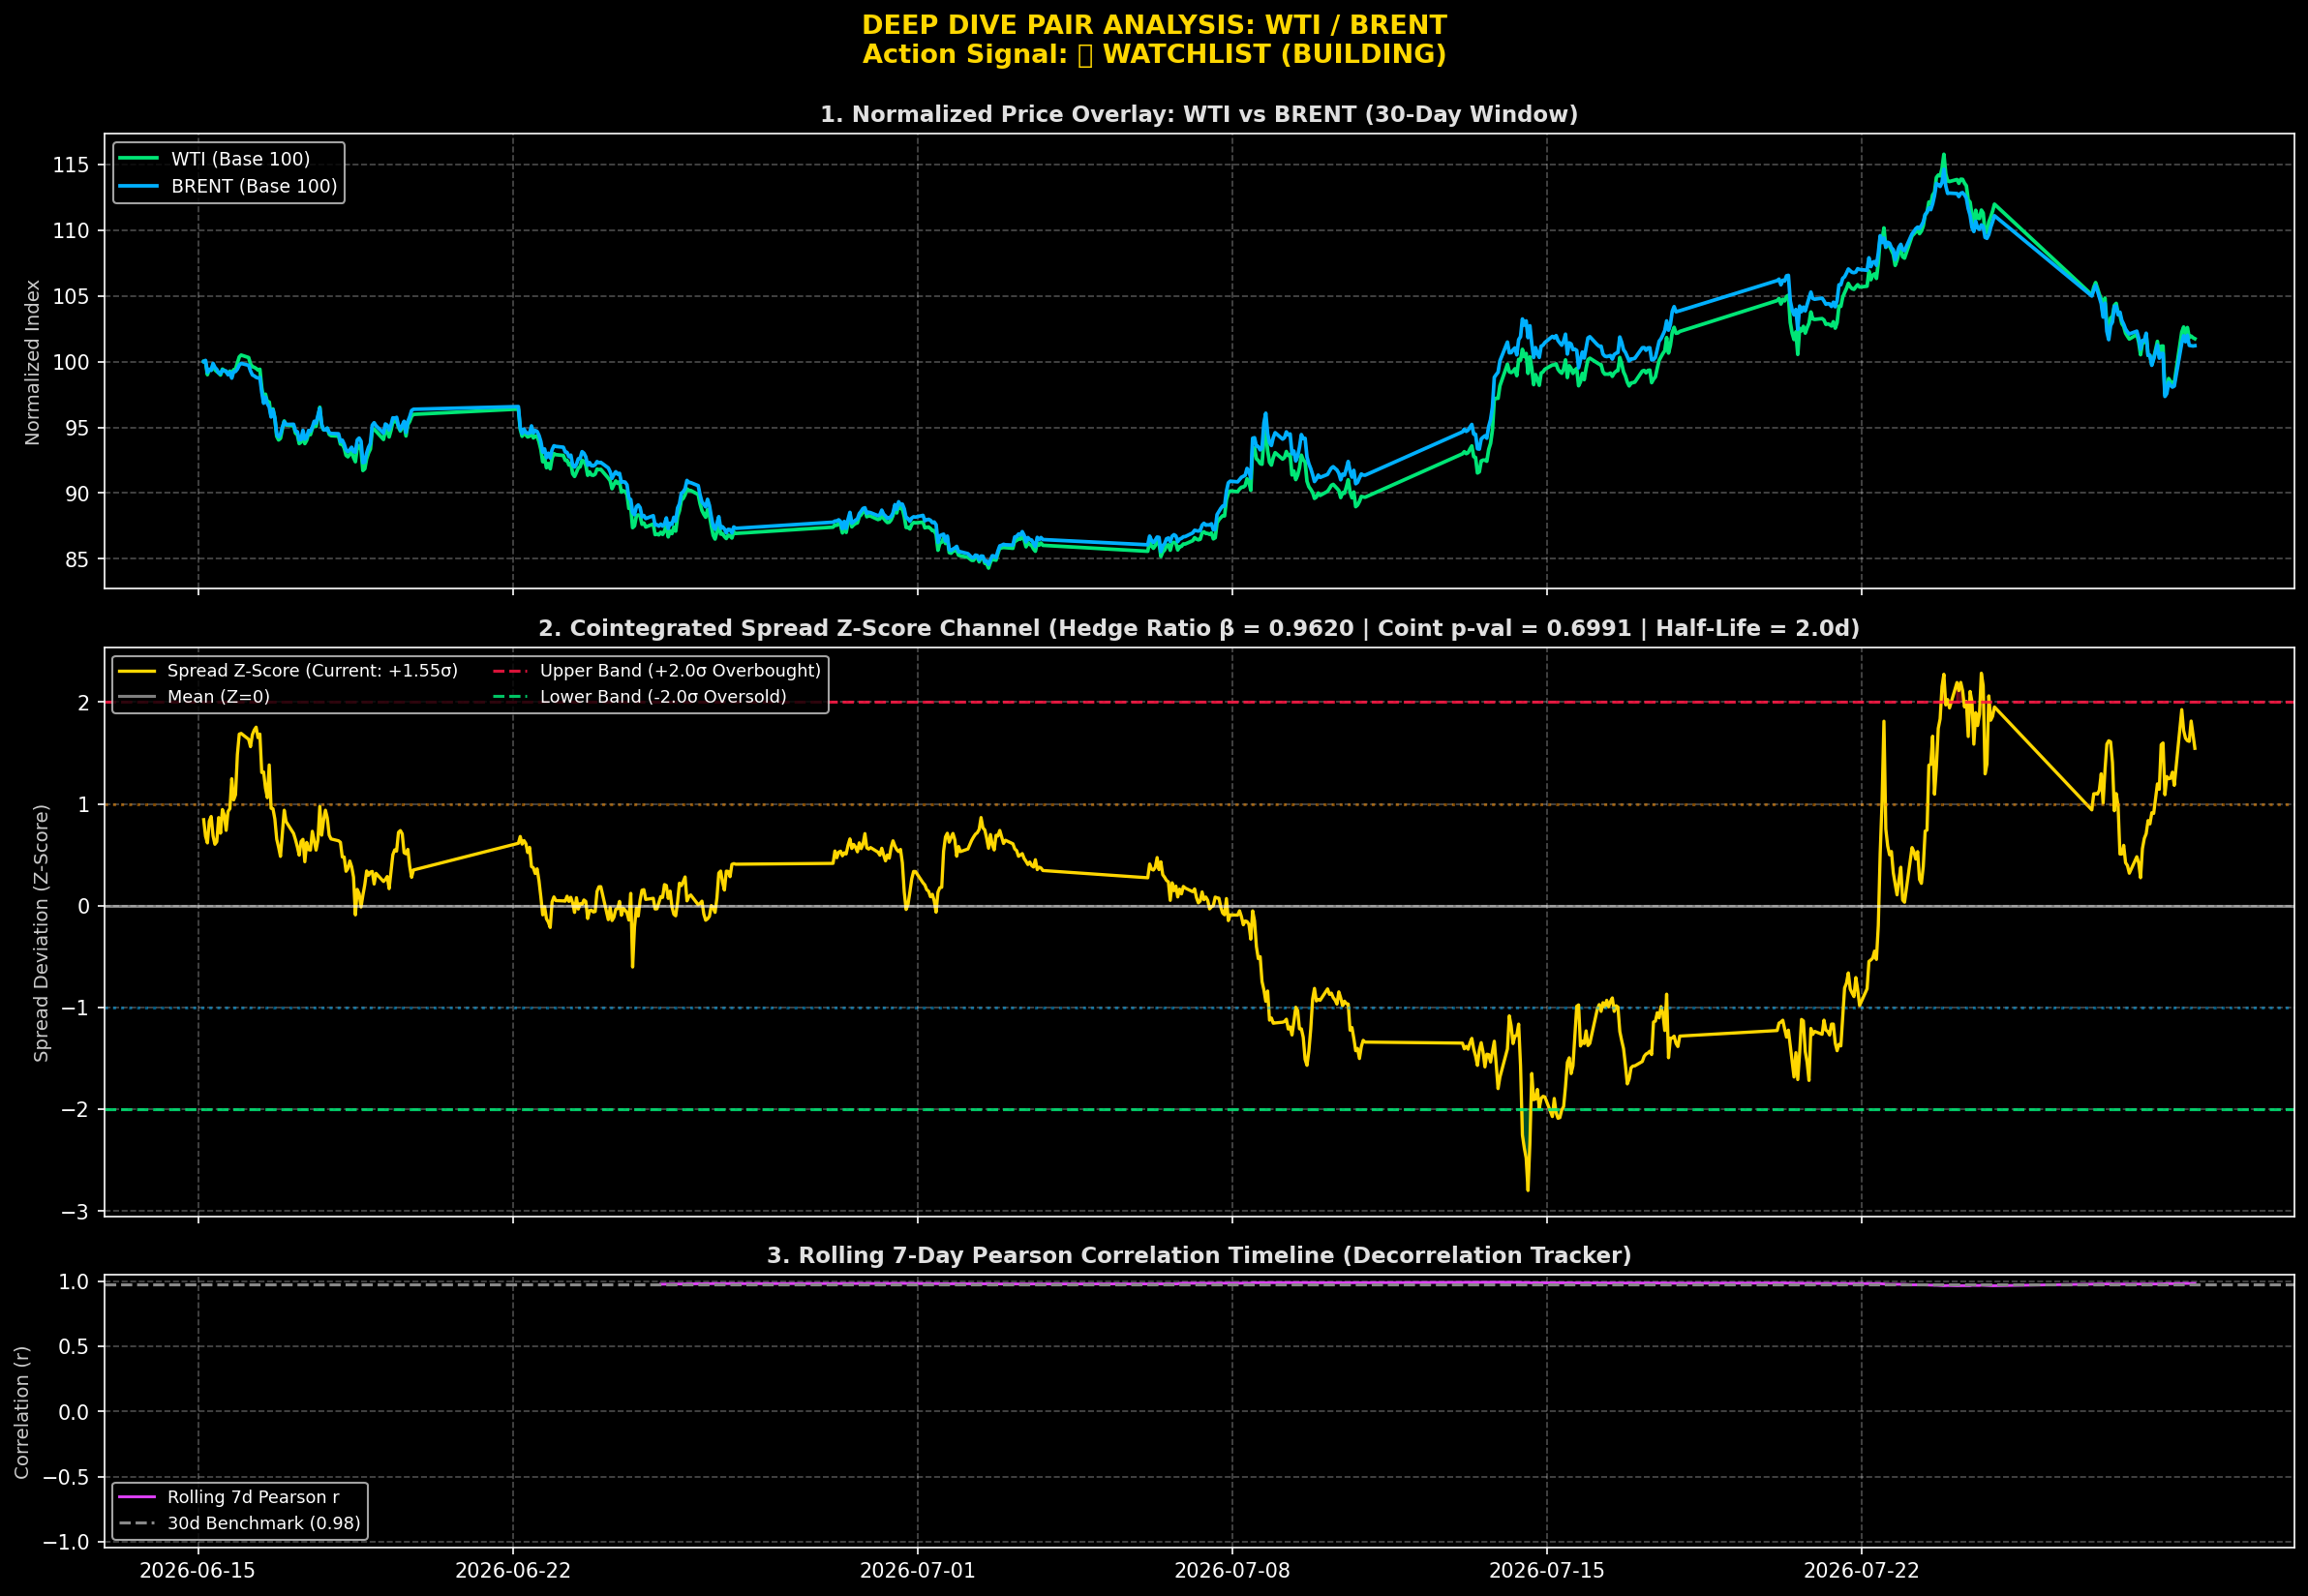

In [21]:
def plot_top_pair_deep_dive(df_prices, df_screener):
    '''Generates normalized price overlay, spread Z-score channel, and correlation timeline for top pair.'''
    top_row = df_screener.iloc[0]
    sym_y = top_row['Asset Y']
    sym_x = top_row['Asset X']
    beta = top_row['Hedge Ratio (β)']
    coint_p = top_row['Coint p-val']
    z_score = top_row['Z-Score']
    hl_days = top_row['Half-Life (Days)']
    signal = top_row['Action Signal']

    bars_per_day = 24
    lookback = min(len(df_prices), 30 * bars_per_day)
    df_sub = df_prices.iloc[-lookback:].copy()

    y = df_sub[sym_y]
    x = df_sub[sym_x]

    # Compute normalized prices (100 base)
    y_norm = (y / y.iloc[0]) * 100.0
    x_norm = (x / x.iloc[0]) * 100.0

    # Compute OLS spread and dynamic Z-score
    alpha = np.polyfit(x, y, 1)[1]
    spread = y - (beta * x + alpha)
    mean_s = spread.mean()
    std_s = spread.std()
    z_series = (spread - mean_s) / std_s

    # Compute rolling 7-day correlation timeline
    roll_corr_7d = y.pct_change().rolling(7*24).corr(x.pct_change())

    fig, axes = plt.subplots(3, 1, figsize=(16, 11), dpi=150, sharex=True, gridspec_kw={'height_ratios': [2, 2.5, 1.2]})

    # Subplot 1: Normalized Price Overlay
    axes[0].plot(y_norm.index, y_norm, color='#00E676', lw=1.8, label=f"{sym_y} (Base 100)")
    axes[0].plot(x_norm.index, x_norm, color='#00B0FF', lw=1.8, label=f"{sym_x} (Base 100)")
    axes[0].set_title(f"1. Normalized Price Overlay: {sym_y} vs {sym_x} (30-Day Window)", fontsize=11, fontweight='bold', color='#E0E0E0')
    axes[0].set_ylabel("Normalized Index", fontsize=9.5, color='#CCCCCC')
    axes[0].grid(True, linestyle='--', alpha=0.3)
    axes[0].legend(loc='upper left', fontsize=9)

    # Subplot 2: Spread Z-Score Arbitrage Channel
    axes[1].plot(z_series.index, z_series, color='#FFD700', lw=1.6, label=f"Spread Z-Score (Current: {z_score:+.2f}σ)")
    axes[1].axhline(0, color='white', linestyle='-', alpha=0.5, label="Mean (Z=0)")
    axes[1].axhline(2.0, color='#FF1744', linestyle='--', alpha=0.85, label="Upper Band (+2.0σ Overbought)")
    axes[1].axhline(-2.0, color='#00E676', linestyle='--', alpha=0.85, label="Lower Band (-2.0σ Oversold)")
    axes[1].axhline(1.0, color='#FF9100', linestyle=':', alpha=0.5)
    axes[1].axhline(-1.0, color='#00B0FF', linestyle=':', alpha=0.5)

    # Highlight extreme divergence zones
    axes[1].fill_between(z_series.index, 2.0, z_series, where=(z_series >= 2.0), color='#FF1744', alpha=0.35)
    axes[1].fill_between(z_series.index, -2.0, z_series, where=(z_series <= -2.0), color='#00E676', alpha=0.35)

    axes[1].set_title(f"2. Cointegrated Spread Z-Score Channel (Hedge Ratio β = {beta:.4f} | Coint p-val = {coint_p:.4f} | Half-Life = {hl_days}d)",
                      fontsize=11, fontweight='bold', color='#E0E0E0')
    axes[1].set_ylabel("Spread Deviation (Z-Score)", fontsize=9.5, color='#CCCCCC')
    axes[1].grid(True, linestyle='--', alpha=0.3)
    axes[1].legend(loc='upper left', fontsize=8.5, ncol=2)

    # Subplot 3: Rolling 7-Day Correlation Timeline
    axes[2].plot(roll_corr_7d.index, roll_corr_7d, color='#E040FB', lw=1.4, label="Rolling 7d Pearson r")
    axes[2].axhline(top_row['30d Corr'], color='#888888', linestyle='--', label=f"30d Benchmark ({top_row['30d Corr']:.2f})")
    axes[2].set_title("3. Rolling 7-Day Pearson Correlation Timeline (Decorrelation Tracker)", fontsize=11, fontweight='bold', color='#E0E0E0')
    axes[2].set_ylabel("Correlation (r)", fontsize=9.5, color='#CCCCCC')
    axes[2].set_ylim(-1.05, 1.05)
    axes[2].grid(True, linestyle='--', alpha=0.3)
    axes[2].legend(loc='lower left', fontsize=8.5)

    title_text = f"DEEP DIVE PAIR ANALYSIS: {sym_y} / {sym_x}\nAction Signal: {signal}"
    plt.suptitle(title_text,
                 fontsize=13, fontweight='bold', color='#FFD700', y=0.995)
    plt.tight_layout()
    plt.show()

plot_top_pair_deep_dive(df_prices, df_screener)


In [22]:
def calculate_position_sizes(df_screener, target_pair_idx=0, account_equity=10000.0, risk_pct=0.01):
    '''Calculates exact MetaTrader 5 lot sizes for Long Y / Short X pairs trade.'''
    row = df_screener.iloc[target_pair_idx]
    sym_y = row['Asset Y']
    sym_x = row['Asset X']
    beta  = row['Hedge Ratio (β)']
    z_val = row['Z-Score']
    signal = row['Action Signal']

    print(f"=== METATRADER 5 POSITION SIZING CALCULATOR ===")
    print(f"Target Pair:           {sym_y} vs {sym_x}")
    print(f"Account Equity:        ${account_equity:,.2f} | Risk Allocation ({risk_pct*100}%): ${account_equity*risk_pct:,.2f}")
    print(f"Spread Z-Score:        {z_val:+.2f}σ")
    print(f"Action Signal:         {signal}")
    print(f"Hedge Ratio (β):       {beta:.4f}")
    print("-" * 55)

    # Default contract size assumption (e.g. 100,000 units for standard Forex lot)
    base_lot_y = 0.10  # 0.10 Lots on primary asset Y
    hedge_lot_x = round(base_lot_y * abs(beta), 2)  # Scale X position by beta

    if "LONG Y" in signal:
        print("👉 EXECUTION PLAN:")
        print(f"   1. BUY  {base_lot_y:.2f} Lots of {sym_y} (Primary Leg)")
        print(f"   2. SELL {hedge_lot_x:.2f} Lots of {sym_x} (Hedge Leg = {base_lot_y:.2f} × {abs(beta):.4f})")
    elif "SHORT Y" in signal:
        print("👉 EXECUTION PLAN:")
        print(f"   1. SELL {base_lot_y:.2f} Lots of {sym_y} (Primary Leg)")
        print(f"   2. BUY  {hedge_lot_x:.2f} Lots of {sym_x} (Hedge Leg = {base_lot_y:.2f} × {abs(beta):.4f})")
    else:
        print(f"👉 EXECUTION PLAN: Stand by. Z-Score ({z_val:+.2f}σ) has not breached ±1.8σ entry threshold.")

    print("-" * 55)
    print("🛡️ RISK & EXIT RULES:")
    print("   • Take Profit (Mean Reversion): Close both legs when Z-Score reaches 0.00σ ± 0.20σ.")
    print("   • Stop Loss (Divergence Expansion): Stop out if Z-Score expands beyond ±3.50σ.")

calculate_position_sizes(df_screener, target_pair_idx=0)


=== METATRADER 5 POSITION SIZING CALCULATOR ===
Target Pair:           WTI vs BRENT
Account Equity:        $10,000.00 | Risk Allocation (1.0%): $100.00
Spread Z-Score:        +1.55σ
Action Signal:         🟡 WATCHLIST (BUILDING)
Hedge Ratio (β):       0.9620
-------------------------------------------------------
👉 EXECUTION PLAN: Stand by. Z-Score (+1.55σ) has not breached ±1.8σ entry threshold.
-------------------------------------------------------
🛡️ RISK & EXIT RULES:
   • Take Profit (Mean Reversion): Close both legs when Z-Score reaches 0.00σ ± 0.20σ.
   • Stop Loss (Divergence Expansion): Stop out if Z-Score expands beyond ±3.50σ.


## Summary & Practical Trading Guidelines

### 1. Daily Workflow
1. Run the **Multi-Asset Data Engine** to pull the latest 30-day H1 price history from MetaTrader 5.
2. Review the **30-Day vs 7-Day Correlation Breakdown Heatmap** to identify asset classes undergoing structural decoupling.
3. Check the **Master Cointegration Table** for pairs with **ADF $p\text{-value} < 0.05$** and **$|Z\text{-score}| > 1.8\sigma$**.

### 2. Execution Discipline
- **Beta Sizing**: Always adjust the volume of Asset X by the Hedge Ratio $\beta$. Trading equal lot sizes breaks delta neutrality and exposes the portfolio to directional market risk!
- **Half-Life Expiry**: If a trade stays open longer than $2.5 \times \text{Half-Life}$ without mean-reverting, close the pair to prevent capital tie-up in structural breakdown.
- **News Avoidance**: Do not open cointegration trades immediately prior to high-impact economic releases (e.g. NFP, CPI, Central Bank Interest Rate Decisions).
